In [1]:
from telescope_reduction import *

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams.update({'axes.linewidth' : 1.5,
                     'ytick.major.width' : 1.5,
                     'ytick.minor.width' : 1.5,
                     'xtick.major.width' : 1.5,
                     'xtick.minor.width' : 1.5,
                     'xtick.labelsize': 12, 
                     'ytick.labelsize': 12,
                     'axes.labelsize': 18,
                     'axes.labelpad' : 5,
                     'axes.titlesize' : 20,
                     'axes.titlepad' : 10,
                     'font.family': 'Serif'
                    })

mpl.rcParams['mathtext.fontset'] = 'cm'          # Computer Modern serif
mpl.rcParams['mathtext.rm'] = 'serif'

In [3]:
folder = "/scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/flt/UVIS2 F845M"
hst_list = fits_to_list(folder, "EXPSTART", "RA_TARG", "DEC_TARG", "ORIENTAT", alt_header=1)

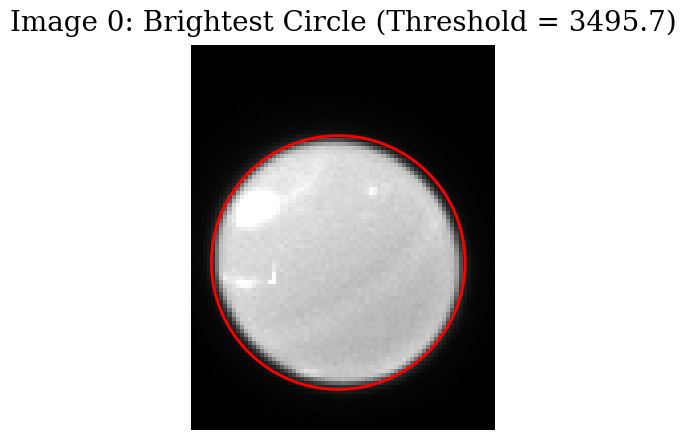

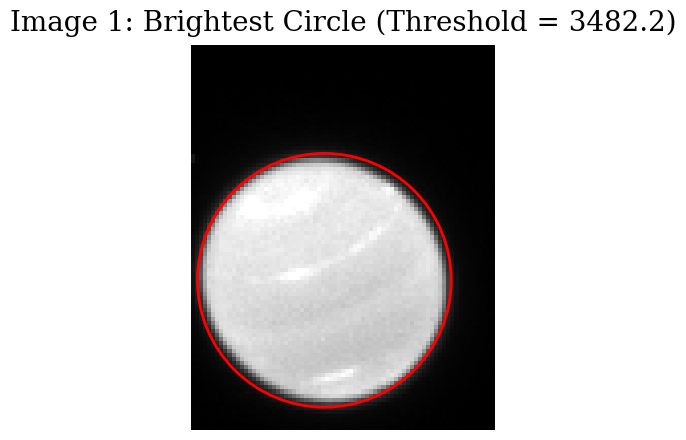

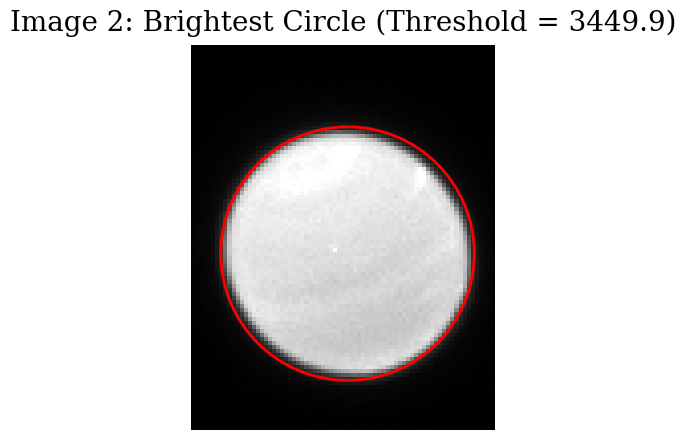

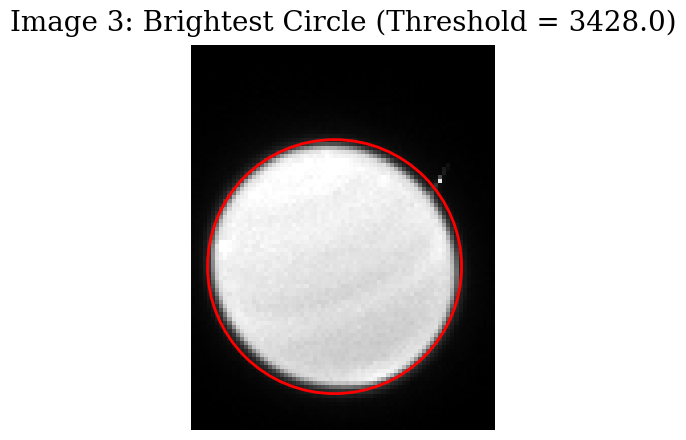

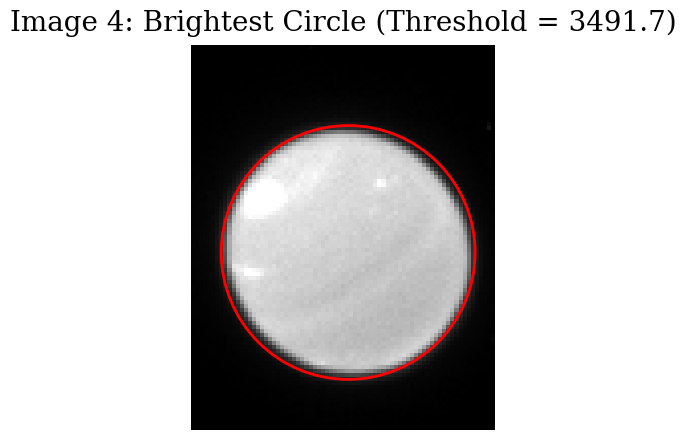

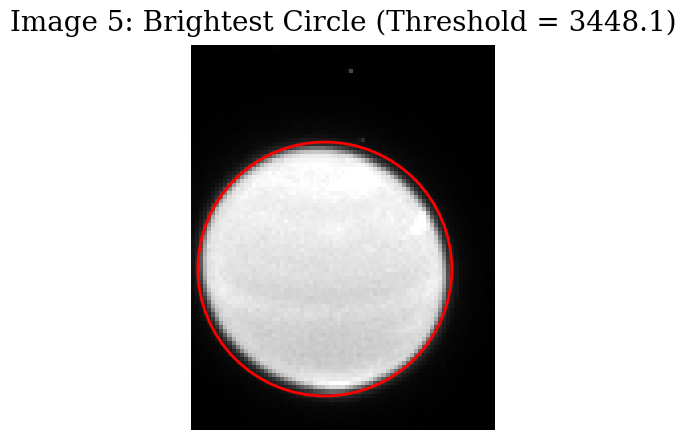

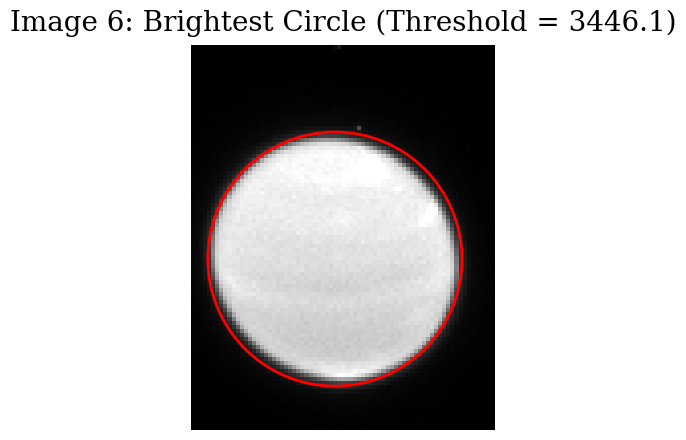

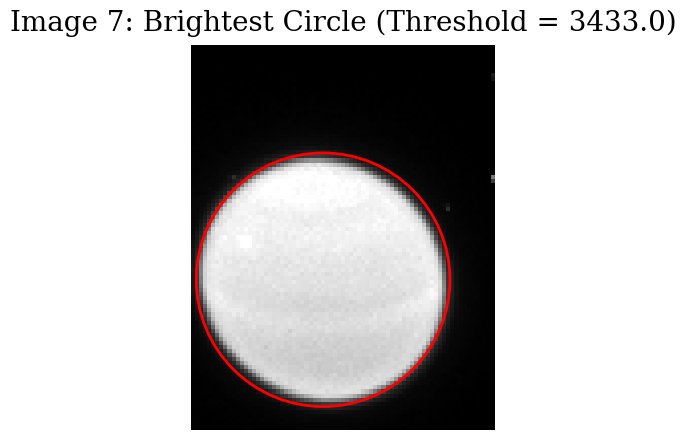

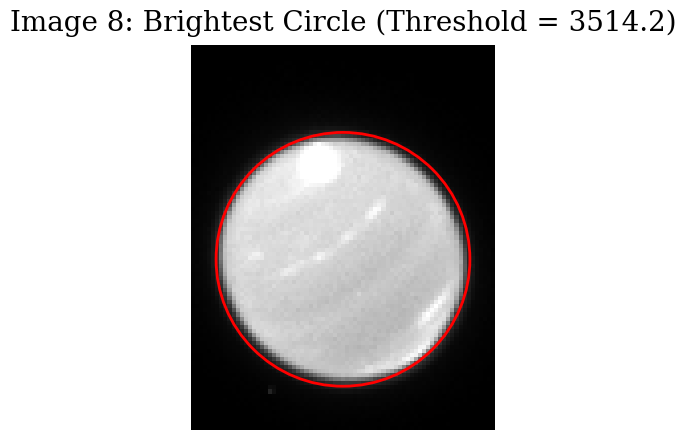

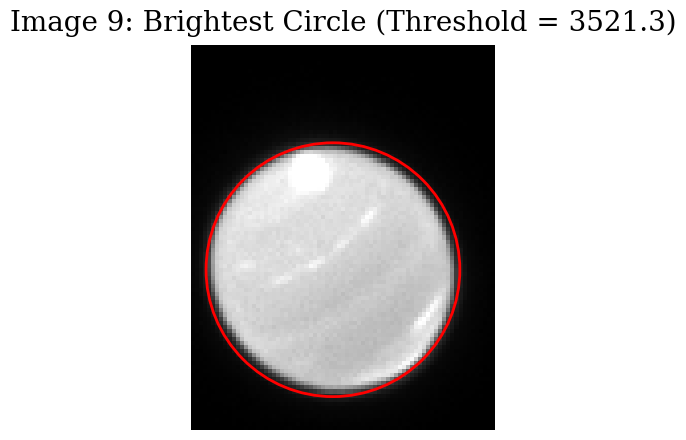

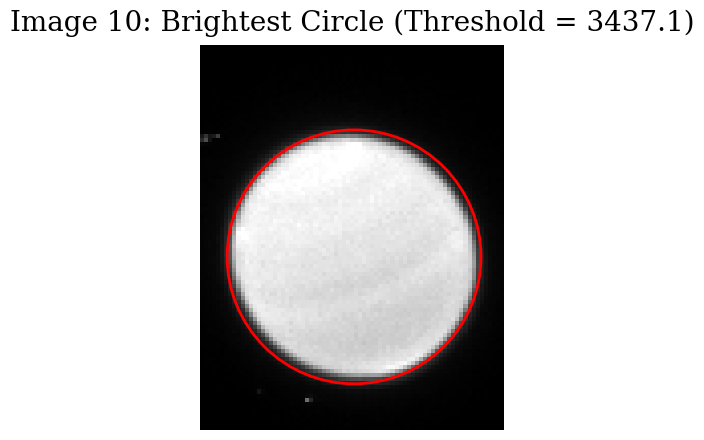

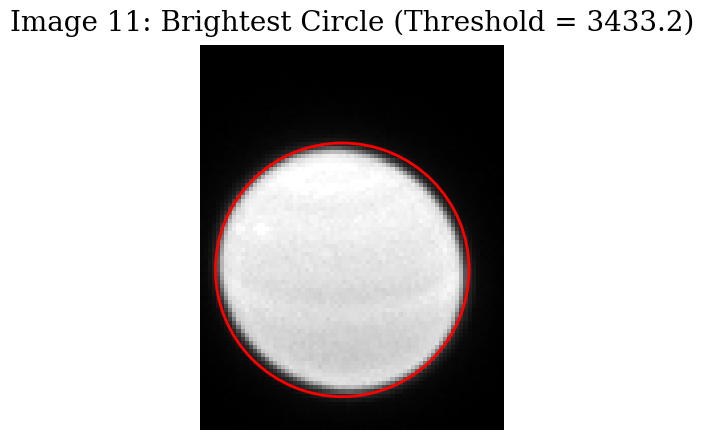

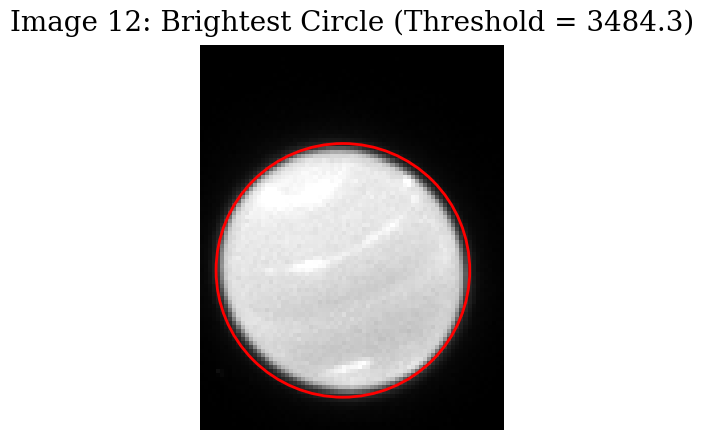

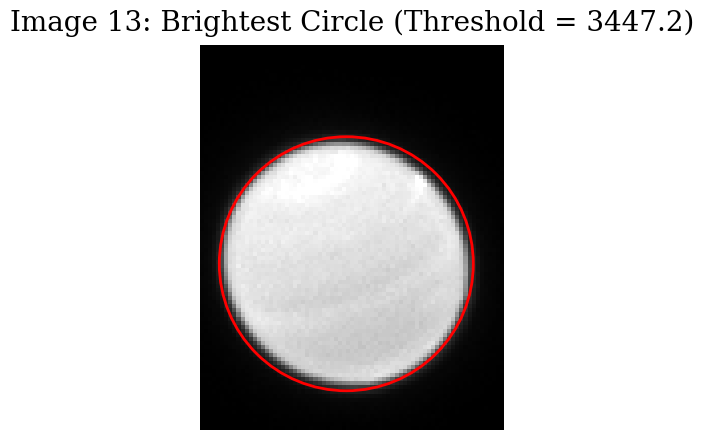

In [4]:
hst_images = [entry['data'] for entry in hst_list]

row_start, row_end = 215, 310
col_start, col_end = 225, 300

cropped_images = [img[row_start:row_end, col_start:col_end] for img in hst_images]

#show_image_list(cropped_images, filter_name="UVIS2 F845M")
results = draw_largest_bright_circle(cropped_images, use_adaptive_threshold=True,
                                percentile_threshold=95,
                                radius_scale=1.05, show=True)

In [5]:
def crop_hst_data(hst_list, row_start, row_end, col_start, col_end):
    """
    Crops the 'data' field of each dictionary in the HST list, preserving metadata.

    Args:
        hst_list (list of dict): List of HST image entries with 'data' and metadata.
        row_start (int): Starting row index for cropping.
        row_end (int): Ending row index for cropping.
        col_start (int): Starting column index for cropping.
        col_end (int): Ending column index for cropping.

    Returns:
        list of dict: New list with cropped 'data' and original metadata preserved.
    """
    cropped_list = []

    for entry in hst_list:
        cropped_entry = entry.copy()  # shallow copy to preserve other keys
        cropped_entry['data'] = entry['data'][row_start:row_end, col_start:col_end]
        cropped_list.append(cropped_entry)

    return cropped_list


In [6]:
def draw_latitude_lines(ax, center, radius, step_deg=15, npoints=360, rotation_deg=0, **kwargs):
    """
    Draw curved latitude lines using orthographic projection of a sphere.
    """
    x0, y0 = center
    phi = np.linspace(0, 2 * np.pi, npoints)  # longitude sweep

    rot = np.radians(rotation_deg)

    for lat_deg in range(-90, 91, step_deg):
        lat_rad = np.radians(lat_deg)

        # 3D sphere coordinates (before rotation)
        x = np.cos(lat_rad) * np.cos(phi)
        y = np.cos(lat_rad) * np.sin(phi)
        z = np.sin(lat_rad) * np.ones_like(phi)

        # Apply rotation around the z-axis
        x_rot = x * np.cos(rot) - y * np.sin(rot)
        y_rot = x * np.sin(rot) + y * np.cos(rot)

        # Orthographic projection: only keep points where z ≥ 0 *after* projection
        visible = x_rot**2 + y_rot**2 <= 1  # inside visible hemisphere

        # Project to 2D plane
        x_proj = radius * x_rot[visible] + x0
        y_proj = radius * z[visible] + y0

        ax.plot(x_proj, y_proj, **kwargs)


def draw_latitude_grid_on_results(fits_list,
                                   detection_func=draw_largest_bright_circle,
                                   step_deg=15,
                                   line_kwargs=None,
                                   **detection_kwargs):
    """
    Calls `detection_func` and overlays latitude lines using detected centers/radii.
    Uses per-image ORIENTAT value from the fits_list.
    """
    if line_kwargs is None:
        line_kwargs = dict(color='cyan', lw=0.8, ls='--')

    # Extract just image arrays for detection
    images = [entry['data'] for entry in fits_list]
    results = detection_func(images, show=False, **detection_kwargs)

    for i, (entry, res) in enumerate(zip(fits_list, results)):
        img = entry['data']
        orientat = entry.get('orientat', 0)  # default to 0° if missing
        position = res.get('position')
        radius = res.get('radius')

        if position is None or radius is None:
            continue

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.imshow(img, origin='lower', cmap='gray',
                  vmin=np.nanpercentile(img, 5), vmax=np.nanpercentile(img, 99))

        draw_latitude_lines(ax, center=position, radius=radius,
                            step_deg=step_deg,
                            rotation_deg=orientat,  # <- Use per-image rotation
                            **line_kwargs)

        circ = plt.Circle(position, radius, edgecolor='red',
                          facecolor='none', lw=2)
        ax.add_patch(circ)

        ax.set_title(f"Image {i}: Latitude Grid + ORIENTAT = {orientat:.1f}°")
        ax.axis('off')
        plt.show()

    return results


ValueError: not enough values to unpack (expected 2, got 1)

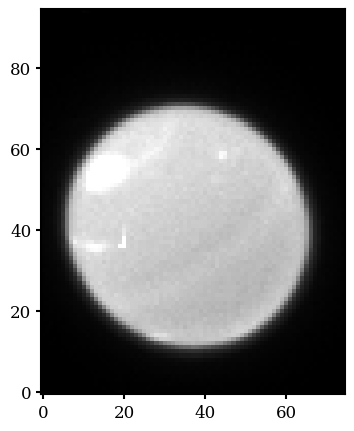

In [7]:
cropped_hst_list = crop_hst_data(hst_list, row_start, row_end, col_start, col_end)
results = draw_latitude_grid_on_results(cropped_hst_list, step_deg=15, radius_scale=1)

In [ ]:
from astropy.io import fits 
from astropy.wcs import WCS

file = "/scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/flt/UVIS2 F763M/ieaq28lcq_flt.fits"
with fits.open(file) as hdul:
    sci_header = hdul[1].header
    fits.info(file)
    wcs = WCS(hdul[1].header, hdul)

print(wcs)

In [ ]:
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.io import fits

with fits.open(file) as hdul:
    wcs = WCS(hdul[1].header, hdul)
    image_data = hdul[1].data
    header = hdul[1].header
    
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection=wcs)
ax.imshow(image_data, origin='lower', cmap='gray', vmin=np.percentile(image_data, 5), vmax=np.percentile(image_data, 99))
ax.set_xlabel('RA')
ax.set_ylabel('Dec')
ax.grid(color='cyan', ls='--')
plt.show()
print(header)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def orthographic_projection(x, y, z):
    """Projects 3D points onto the 2D plane (only visible front hemisphere)."""
    visible = x**2 + y**2 + z**2 <= 1  # restrict to unit sphere surface
    return x[visible], y[visible], z[visible]

def plot_sphere_with_grid(radius=1.0, step_deg=15, n_points=360, 
                          rotation_deg=0, inclination_deg=0):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect('equal')

    phi = np.linspace(0, 2 * np.pi, n_points)  # azimuth (longitude)
    theta = np.linspace(-np.pi / 2, np.pi / 2, n_points)  # latitude

    rot_z = np.radians(rotation_deg)        # Z-axis (longitude) rotation
    rot_x = np.radians(inclination_deg)     # X-axis (inclination) rotation

    def rotate_xyz(x, y, z):
        """Apply X then Z rotation to 3D coordinates."""
        # Rotate around X (inclination)
        y2 = y * np.cos(rot_x) - z * np.sin(rot_x)
        z2 = y * np.sin(rot_x) + z * np.cos(rot_x)
        x2 = x

        # Rotate around Z (longitude)
        x3 = x2 * np.cos(rot_z) - y2 * np.sin(rot_z)
        y3 = x2 * np.sin(rot_z) + y2 * np.cos(rot_z)
        z3 = z2

        return x3, y3, z3

    # Latitude lines
    for lat_deg in range(-90, 91, step_deg):
        lat_rad = np.radians(lat_deg)
        x = np.cos(lat_rad) * np.cos(phi)
        y = np.cos(lat_rad) * np.sin(phi)
        z = np.sin(lat_rad) * np.ones_like(phi)

        x_r, y_r, z_r = rotate_xyz(x, y, z)
        x_proj, y_proj, z_proj = orthographic_projection(x_r, y_r, z_r)
        ax.plot(x_proj * radius, y_proj * radius, color='gray', lw=0.8)

    # Longitude lines
    for lon_deg in range(0, 360, step_deg):
        lon_rad = np.radians(lon_deg)
        x = np.cos(theta) * np.cos(lon_rad)
        y = np.cos(theta) * np.sin(lon_rad)
        z = np.sin(theta)

        x_r, y_r, z_r = rotate_xyz(x, y, z)
        x_proj, y_proj, z_proj = orthographic_projection(x_r, y_r, z_r)
        ax.plot(x_proj * radius, y_proj * radius, color='gray', lw=0.8)

    # Outline of the planet
    circle = plt.Circle((0, 0), radius, edgecolor='black', facecolor='none', lw=1.5)
    ax.add_patch(circle)

    ax.set_xlim(-radius, radius)
    ax.set_ylim(-radius, radius)
    ax.axis('off')
    ax.set_title(f'Orthographic Sphere\nRot: {rotation_deg}°, Incl: {inclination_deg}°')
    plt.show()

# Example usage
plot_sphere_with_grid(rotation_deg=0, inclination_deg=90)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, exposure, feature
from skimage.transform import hough_line, hough_line_peaks
from skimage.color import gray2rgb

def detect_latitude_bands(img, num_lines=5, sigma=2.0, threshold_rel=0.8, plot=True):
    """
    Detects bright linear features in the image (e.g., latitude bands)
    and overlays lines on the detected directions.
    
    Parameters:
        img (2D array): Grayscale image of a planet.
        num_lines (int): Number of lines to overlay.
        sigma (float): Gaussian sigma for edge detection.
        threshold_rel (float): Relative threshold for peak detection.
        plot (bool): Whether to display the result.
    
    Returns:
        lines (list): Detected line parameters (angle, dist).
    """
    # Step 1: Normalize and smooth
    img_smooth = filters.gaussian(img, sigma=sigma)
    img_rescaled = exposure.rescale_intensity(img_smooth, in_range='image', out_range=(0, 1))
    img_eq = exposure.equalize_adapthist(img_rescaled)

    # Step 2: Edge detection (alternatively, ridge filter)
    edges = filters.sobel(img_eq)

    # Step 3: Hough transform
    h, theta, d = hough_line(edges)

    # Step 4: Extract top lines
    accum, angles, dists = hough_line_peaks(h, theta, d, num_peaks=num_lines)

    lines = list(zip(angles, dists))

    if plot:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(img, cmap='gray', origin='lower')
        rows, cols = img.shape
        for angle, dist in lines:
            y0 = (dist - 0 * np.cos(angle)) / np.sin(angle)
            y1 = (dist - cols * np.cos(angle)) / np.sin(angle)
            ax.plot((0, cols), (y0, y1), '-r', lw=2)
        ax.set_title('Detected Bright Latitude Bands')
        ax.axis('off')
        plt.show()

    return lines


In [ ]:
# hst_list = your FITS list
cropped_hst_list = crop_hst_data(hst_list, row_start, row_end, col_start, col_end)

img = cropped_hst_list[5]['data']
detect_latitude_bands(img, num_lines=5, sigma=3)


In [ ]:
plt.imshow(image, vmin=0, vmax=np.percentile(image, 99.999))
print(np.max(result), np.min(result))

In [ ]:
from astropy.io import fits
from skimage.exposure import rescale_intensity
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Load and convert to float ---
image = fits.getdata(file).astype(float)
image = image[row_start:row_end, col_start:col_end]

# Optional: remove sky background
image -= np.percentile(image, 5)

# --- 2. Smooth the background slightly to isolate sharp features ---
smoothed = gaussian_filter(image, sigma=3)

# --- 3. Subtract smoothed image to emphasize high-frequency clouds ---
highpass = image - smoothed

# --- 4. Rescale for visibility ---
p1, p99 = np.percentile(highpass, (1, 99))
stretched = rescale_intensity(highpass, in_range=(p1, p99), out_range=(0, 1))

# --- 5. Display ---
plt.imshow(stretched, cmap='viridis', vmin=np.percentile(stretched, 10), vmax=np.percentile(stretched, 99))
#plt.title("Neptune Cloud Enhancements")
#plt.colorbar()
plt.show()


In [ ]:
detect_latitude_bands(stretched, num_lines=1, sigma=3)

In [ ]:
def apply_soft_limb_mask(image, center, radius, margin=0.1, power=2.0):
    """
    Applies a soft radial mask that fades out near the limb of the planet.

    Parameters:
        image (2D np.ndarray): Input image.
        center (tuple): (x_center, y_center) of the planet (in pixels).
        radius (float): Radius of the planet (in pixels).
        margin (float): Fraction of radius to apply falloff (e.g. 0.1 = 10%).
        power (float): Controls the steepness of the falloff (2 = cosine-like, >2 = sharper).

    Returns:
        masked_image (2D np.ndarray): Image with soft radial fade.
        weight_mask (2D float array): Float mask from 0 to 1 (same shape as image).
    """
    ny, nx = image.shape
    Y, X = np.meshgrid(np.arange(ny), np.arange(nx), indexing='ij')
    r = np.sqrt((X - center[0])**2 + (Y - center[1])**2)

    # Define inner and outer bounds for soft fade
    inner = radius * (1 - margin)
    outer = radius

    # Normalize radial distance for fade zone
    normalized = (outer - r) / (outer - inner)
    normalized = np.clip(normalized, 0, 1)

    # Apply smooth falloff using power-law (soft edge)
    weight_mask = normalized ** power

    # Apply the mask
    masked_image = image * weight_mask

    return masked_image, weight_mask


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, exposure
from skimage.transform import hough_line, hough_line_peaks

def detect_latitude_bands(img, num_lines=1, sigma=2.0):
    """Detects latitude-like bands and returns (angle, dist)."""
    img_smooth = filters.gaussian(img, sigma=sigma)
    img_rescaled = exposure.rescale_intensity(img_smooth, in_range='image', out_range=(0, 1))
    img_eq = exposure.equalize_adapthist(img_rescaled)
    edges = filters.sobel(img_eq)
    h, theta, d = hough_line(edges)
    accum, angles, dists = hough_line_peaks(h, theta, d, num_peaks=num_lines)
    return list(zip(angles, dists))

def overlay_grid_on_image(img, radius, position,
                          step_deg=15, n_points=360, 
                          rotation_deg=0, inclination_deg=0):
    """
    Overlay a latitude/longitude grid on top of the given image.

    Parameters:
        img (2D np.ndarray): Image to overlay grid on.
        radius (float): Radius of the projected sphere in pixels.
        position (tuple): (x_center, y_center) of the sphere in pixels.
        step_deg (int): Step size for lat/lon lines (in degrees).
        n_points (int): Resolution of grid curves.
        rotation_deg (float): Rotation around Z-axis (longitude).
        inclination_deg (float): Inclination around X-axis (latitude).
    """
    import numpy as np
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img, cmap='gray', origin='lower')
    ax.set_aspect('equal')

    phi = np.linspace(0, 2 * np.pi, n_points)
    theta = np.linspace(-np.pi / 2, np.pi / 2, n_points)

    rot_z = np.radians(rotation_deg)
    rot_x = np.radians(inclination_deg)

    def rotate_xyz(x, y, z):
        # Rotate around X
        y2 = y * np.cos(rot_x) - z * np.sin(rot_x)
        z2 = y * np.sin(rot_x) + z * np.cos(rot_x)
        x2 = x
        # Rotate around Z
        x3 = x2 * np.cos(rot_z) - y2 * np.sin(rot_z)
        y3 = x2 * np.sin(rot_z) + y2 * np.cos(rot_z)
        z3 = z2
        return x3, y3, z3

    def orthographic_projection(x, y, z):
        visible = z >= 0
        return x[visible], y[visible], z[visible]

    # Use provided center position (x, y)
    cx, cy = position

    # Latitude lines
    for lat_deg in range(-90, 91, step_deg):
        lat_rad = np.radians(lat_deg)
        x = np.cos(lat_rad) * np.cos(phi)
        y = np.cos(lat_rad) * np.sin(phi)
        z = np.sin(lat_rad) * np.ones_like(phi)

        x_r, y_r, z_r = rotate_xyz(x, y, z)
        x_proj, y_proj, _ = orthographic_projection(x_r, y_r, z_r)
        ax.plot(cx + radius * x_proj, cy + radius * y_proj, color='lime', lw=0.8)

    # Longitude lines
    for lon_deg in range(0, 360, step_deg):
        lon_rad = np.radians(lon_deg)
        x = np.cos(theta) * np.cos(lon_rad)
        y = np.cos(theta) * np.sin(lon_rad)
        z = np.sin(theta)

        x_r, y_r, z_r = rotate_xyz(x, y, z)
        x_proj, y_proj, _ = orthographic_projection(x_r, y_r, z_r)
        ax.plot(cx + radius * x_proj, cy + radius * y_proj, color='cyan', lw=0.8)

    ax.set_xlim(0, img.shape[1])
    ax.set_ylim(0, img.shape[0])
    ax.axis('off')
    ax.set_title(f"Grid Overlay\nCenter: ({cx:.1f}, {cy:.1f}), Radius: {radius}px")
    plt.show()

# --- Example usage ---
from astropy.io import fits

# Load FITS image and normalize
img = stretched
img -= np.percentile(img, 5)

results = draw_largest_bright_circle([stretched], use_adaptive_threshold=True,
                                percentile_threshold=50,
                                radius_scale=2, show=True)

# Detect first bright band
lines = detect_latitude_bands(img, num_lines=1, sigma=3.0)
if not lines:
    raise RuntimeError("No latitude bands found.")
angle_rad = lines[0][0]
angle_deg = np.degrees(angle_rad)

# Convert image-space angle to sphere inclination
inclination_deg = 90 - angle_deg

# Overlay grid aligned with detected band
overlay_grid_on_image(img, [entry['radius'] for entry in results], [entry['position'] for entry in results][0], inclination_deg=inclination_deg)


In [ ]:
# Apply smooth limb suppression
soft_image, mask = apply_soft_limb_mask(image, results[0]['position'],     # single (x, y) tuple
    results[0]['radius'], margin=0.3, power=4)

soft_image_rescaled = rescale_intensity(soft_image, in_range='image', out_range=(0, 1))

# Optional: remove sky background
image -= np.percentile(soft_image, 5)

# --- 2. Smooth the background slightly to isolate sharp features ---
smoothed = gaussian_filter(image, sigma=3)

# --- 3. Subtract smoothed image to emphasize high-frequency clouds ---
highpass = image - smoothed

# --- 4. Rescale for visibility ---
p_lowr, p_high = np.percentile(highpass, (40, 99))
stretched = rescale_intensity(highpass, in_range=(p_lowr, p_high), out_range=(0, 1))

# Apply contrast enhancement to the masked image
from skimage.exposure import equalize_adapthist
stretched = equalize_adapthist(stretched)

plt.imshow(stretched)